In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [13]:
df=pd.read_csv('MagicBricks.csv')
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [14]:
df.head

<bound method NDFrame.head of          Area  BHK  Bathroom      Furnishing  \
0       800.0    3       2.0  Semi-Furnished   
1       750.0    2       2.0  Semi-Furnished   
2       950.0    2       2.0       Furnished   
3       600.0    2       2.0  Semi-Furnished   
4       650.0    2       2.0  Semi-Furnished   
...       ...  ...       ...             ...   
1254   4118.0    4       5.0     Unfurnished   
1255   1050.0    3       2.0  Semi-Furnished   
1256    875.0    3       3.0  Semi-Furnished   
1257    990.0    2       2.0     Unfurnished   
1258  11050.0    3       3.0     Unfurnished   

                                               Locality  Parking     Price  \
0                                      Rohini Sector 25      1.0   6500000   
1                J R Designers Floors, Rohini Sector 24      1.0   5000000   
2                   Citizen Apartment, Rohini Sector 13      1.0  15500000   
3                                      Rohini Sector 24      1.0   4200000   
4  

In [15]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   str    
 4   Locality     1259 non-null   str    
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   str    
 8   Transaction  1259 non-null   str    
 9   Type         1254 non-null   str    
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 108.3 KB


In [17]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [18]:
df.shape

(1259, 11)

In [19]:
## missing values

df.isnull().sum

<bound method DataFrame.sum of        Area    BHK  Bathroom  Furnishing  Locality  Parking  Price  Status  \
0     False  False     False       False     False    False  False   False   
1     False  False     False       False     False    False  False   False   
2     False  False     False       False     False    False  False   False   
3     False  False     False       False     False    False  False   False   
4     False  False     False       False     False    False  False   False   
...     ...    ...       ...         ...       ...      ...    ...     ...   
1254  False  False     False       False     False    False  False   False   
1255  False  False     False       False     False    False  False   False   
1256  False  False     False       False     False    False  False   False   
1257  False  False     False       False     False    False  False   False   
1258  False  False     False       False     False    False  False   False   

      Transaction   Type  Per_Sq

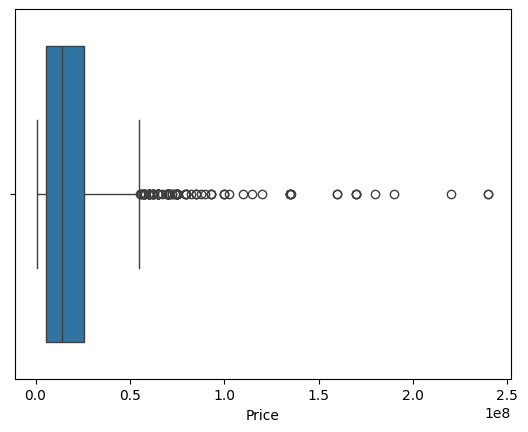

In [20]:
sns.boxplot(x=df['Price'])
plt.show()

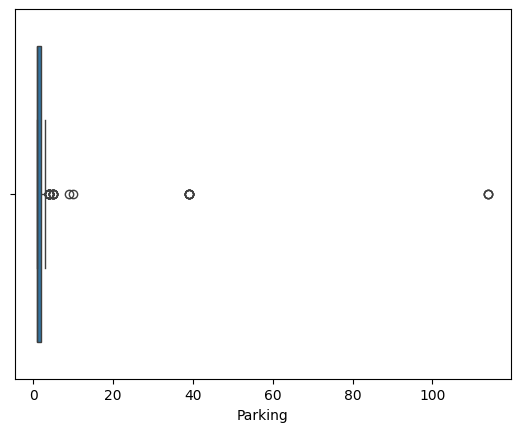

In [22]:
sns.boxplot(x=df['Parking'])
plt.show()
            

In [23]:
df.describe


<bound method NDFrame.describe of          Area  BHK  Bathroom      Furnishing  \
0       800.0    3       2.0  Semi-Furnished   
1       750.0    2       2.0  Semi-Furnished   
2       950.0    2       2.0       Furnished   
3       600.0    2       2.0  Semi-Furnished   
4       650.0    2       2.0  Semi-Furnished   
...       ...  ...       ...             ...   
1254   4118.0    4       5.0     Unfurnished   
1255   1050.0    3       2.0  Semi-Furnished   
1256    875.0    3       3.0  Semi-Furnished   
1257    990.0    2       2.0     Unfurnished   
1258  11050.0    3       3.0     Unfurnished   

                                               Locality  Parking     Price  \
0                                      Rohini Sector 25      1.0   6500000   
1                J R Designers Floors, Rohini Sector 24      1.0   5000000   
2                   Citizen Apartment, Rohini Sector 13      1.0  15500000   
3                                      Rohini Sector 24      1.0   4200000   

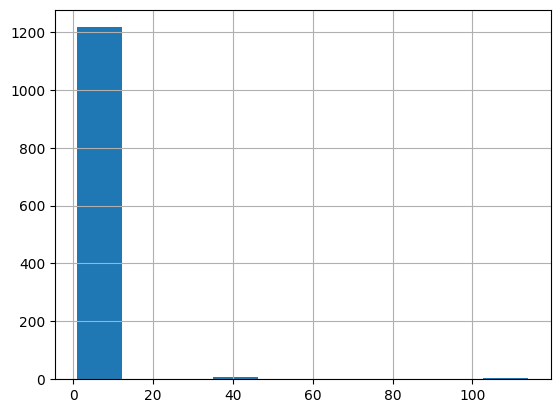

In [24]:
df['Parking'].hist()
plt.show()

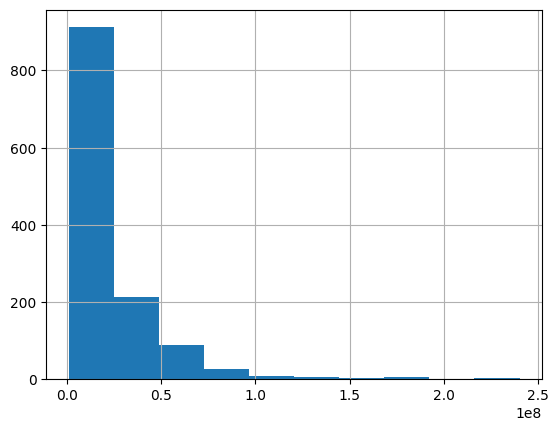

In [25]:
df['Price'].hist()
plt.show()

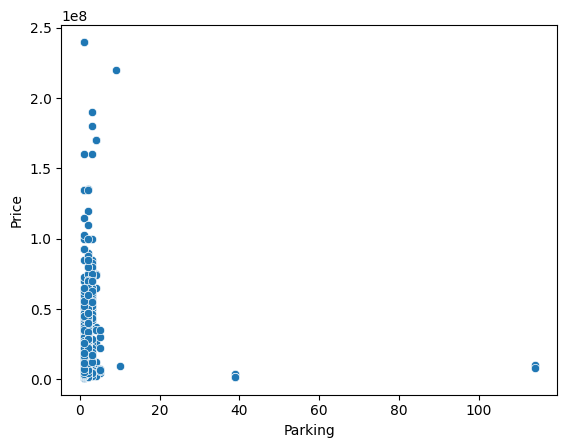

In [26]:
sns.scatterplot(x='Parking',y='Price',data=df)
plt.show()

In [28]:
df[['Parking','Price']].corr()  ##### corelation

,Parking,Price
Parking,1.000000,-0.000448
Price,-0.000448,1.000000


In [29]:
####### feautre slection

x=df[['Parking']]
y=df['Price']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
model = LinearRegression()

In [32]:
model.fit(X_train,y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values